# Assignment 3
## Part 1: Stitching pairs of images 
Mohammad Rashiqul Alam  
malam25@illinois.edu  

In [1]:
# Imports
import numpy as np
# Avoid clash with scipy.io from wildcard imports
import cv2
import matplotlib.pyplot as plt
import skimage.io as skio  
from skimage import color, img_as_float
from skimage.transform import ProjectiveTransform, warp, rotate
from scipy.spatial.distance import cdist
from scipy.optimize import minimize



### Starter Code from Assignment
http://luthuli.cs.uiuc.edu/~daf/Courses/CV2025/Assignments/Assignment3-25-daf.html  
DO NOT EDIT

In [2]:
##############################################
### Provided code - nothing to change here ###
##############################################

"""
Harris Corner Detector
Usage: Call the function harris(filename) for corner detection
Reference   (Code adapted from):
             http://www.kaij.org/blog/?p=89
             Kai Jiang - Harris Corner Detector in Python
             
"""
from pylab import *
from scipy import signal
from scipy import *
import numpy as np
from PIL import Image

def harris(filename, min_distance = 10, threshold = 0.1):
    """
    filename: Path of image file
    threshold: (optional)Threshold for corner detection
    min_distance : (optional)Minimum number of pixels separating 
     corners and image boundary
    """
    im = np.array(Image.open(filename).convert("L"))
    harrisim = compute_harris_response(im)
    filtered_coords = get_harris_points(harrisim,min_distance, threshold)
    plot_harris_points(im, filtered_coords)

def gauss_derivative_kernels(size, sizey=None):
    """ returns x and y derivatives of a 2D 
        gauss kernel array for convolutions """
    size = int(size)
    if not sizey:
        sizey = size
    else:
        sizey = int(sizey)
    y, x = mgrid[-size:size+1, -sizey:sizey+1]
    #x and y derivatives of a 2D gaussian with standard dev half of size
    # (ignore scale factor)
    gx = - x * exp(-(x**2/float((0.5*size)**2)+y**2/float((0.5*sizey)**2))) 
    gy = - y * exp(-(x**2/float((0.5*size)**2)+y**2/float((0.5*sizey)**2))) 
    return gx,gy

def gauss_kernel(size, sizey = None):
    """ Returns a normalized 2D gauss kernel array for convolutions """
    size = int(size)
    if not sizey:
        sizey = size
    else:
        sizey = int(sizey)
    x, y = mgrid[-size:size+1, -sizey:sizey+1]
    g = exp(-(x**2/float(size)+y**2/float(sizey)))
    return g / g.sum()

def compute_harris_response(im):
    """ compute the Harris corner detector response function 
        for each pixel in the image"""
    #derivatives
    gx,gy = gauss_derivative_kernels(3)
    imx = signal.convolve(im,gx, mode='same')
    imy = signal.convolve(im,gy, mode='same')
    #kernel for blurring
    gauss = gauss_kernel(3)
    #compute components of the structure tensor
    Wxx = signal.convolve(imx*imx,gauss, mode='same')
    Wxy = signal.convolve(imx*imy,gauss, mode='same')
    Wyy = signal.convolve(imy*imy,gauss, mode='same')   
    #determinant and trace
    Wdet = Wxx*Wyy - Wxy**2
    Wtr = Wxx + Wyy   
    return Wdet / Wtr

def get_harris_points(harrisim, min_distance=10, threshold=0.1):
    """ return corners from a Harris response image
        min_distance is the minimum nbr of pixels separating 
        corners and image boundary"""
    #find top corner candidates above a threshold
    corner_threshold = max(harrisim.ravel()) * threshold
    harrisim_t = (harrisim > corner_threshold) * 1    
    #get coordinates of candidates
    candidates = harrisim_t.nonzero()
    coords = [ (candidates[0][c],candidates[1][c]) for c in range(len(candidates[0]))]
    #...and their values
    candidate_values = [harrisim[c[0]][c[1]] for c in coords]    
    #sort candidates
    index = argsort(candidate_values)   
    #store allowed point locations in array
    allowed_locations = zeros(harrisim.shape)
    allowed_locations[min_distance:-min_distance,min_distance:-min_distance] = 1   
    #select the best points taking min_distance into account
    filtered_coords = []
    for i in index:
        if allowed_locations[coords[i][0]][coords[i][1]] == 1:
            filtered_coords.append(coords[i])
            allowed_locations[(coords[i][0]-min_distance):(coords[i][0]+min_distance),
                (coords[i][1]-min_distance):(coords[i][1]+min_distance)] = 0               
    return filtered_coords

def plot_harris_points(image, filtered_coords):
    """ plots corners found in image"""
    figure()
    gray()
    imshow(image)
    plot([p[1] for p in filtered_coords],[p[0] for p in filtered_coords],'r*')
    axis('off')
    show()

# Usage: 
#harris('./path/to/image.jpg')


# Provided code for plotting inlier matches between two images

def plot_inlier_matches(ax, img1, img2, inliers):
    """
    Plot the matches between two images according to the matched keypoints
    :param ax: plot handle
    :param img1: left image
    :param img2: right image
    :inliers: x,y in the first image and x,y in the second image (Nx4)
    """
    res = np.hstack([img1, img2])
    ax.set_aspect('equal')
    ax.imshow(res, cmap='gray')
    
    ax.plot(inliers[:,0], inliers[:,1], '+r')
    ax.plot(inliers[:,2] + img1.shape[1], inliers[:,3], '+r')
    ax.plot([inliers[:,0], inliers[:,2] + img1.shape[1]],
            [inliers[:,1], inliers[:,3]], 'r', linewidth=0.4)
    ax.axis('off')
    
# Usage:
# fig, ax = plt.subplots(figsize=(20,10))
# plot_inlier_matches(ax, img1, img2, computed_inliers)

### Implementation Starts Here
Load both images, convert to double and to grayscale

In [3]:
# Load the images
left_rgb  = img_as_float(skio.imread('left.jpg'))
right_rgb = img_as_float(skio.imread('right.jpg'))

# Convert to double precision
left_rgb_f64  = left_rgb.astype(np.float64)
right_rgb_f64 = right_rgb.astype(np.float64)

# Convert to grayscale
left  = color.rgb2gray(left_rgb_f64)
right = color.rgb2gray(right_rgb_f64)

### Detect feature points in both images
Using Harris detector code from the code provided

/tmp/ipykernel_1835/254106298.py:73: RuntimeWarning: divide by zero encountered in divide
  return Wdet / Wtr


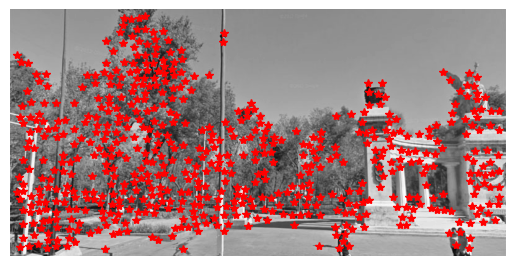

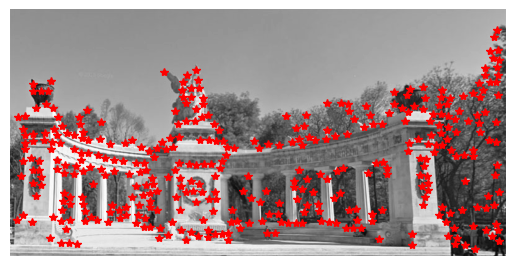

In [4]:
# Detect Harris corners
corners_left  = harris('left.jpg')
corners_right = harris('right.jpg')

### Explore SIFT Descriptors
Utilize SIFT descriptor from OpenCV library to extract keypoints and compute descriptors

In [5]:
# Use SIFT to compute descriptors at the detected corners
# OpenCV's SIFT requires uint8 grayscale images
left_u8  = (left * 255).astype(np.uint8)
right_u8 = (right * 255).astype(np.uint8)

# Create a SIFT object
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints_left, descriptors_left = sift.detectAndCompute(left_u8, None)
keypoints_right, descriptors_right = sift.detectAndCompute(right_u8, None)

print(f"SIFT: left keypoints={len(keypoints_left)}, right keypoints={len(keypoints_right)}")
print(f"SIFT: left descriptors shape={None if descriptors_left is None else descriptors_left.shape}")
print(f"SIFT: right descriptors shape={None if descriptors_right is None else descriptors_right.shape}")
print()


SIFT: left keypoints=4388, right keypoints=3468
SIFT: left descriptors shape=(4388, 128)
SIFT: right descriptors shape=(3468, 128)



### Match SIFT Descriptors between Left and Right Images

In [6]:
# Extract keypoint coordinates from SIFT keypoint objects
keypoints_left_coords = np.array([kp.pt for kp in keypoints_left], dtype=np.float64)
keypoints_right_coords = np.array([kp.pt for kp in keypoints_right], dtype=np.float64)

print(f"Left keypoints:  {keypoints_left_coords.shape[0]}")
print(f"Right keypoints: {keypoints_right_coords.shape[0]}\n")

# Guard against empty descriptor sets
if descriptors_left is None or descriptors_right is None or len(descriptors_left) == 0 or len(descriptors_right) == 0:
    raise ValueError("No descriptors found in one or both images.")

# Compute pairwise squared Euclidean distances between all descriptor pairs
# Shape: (num_left, num_right)
descriptor_distances = cdist(descriptors_left, descriptors_right, metric='sqeuclidean')

print(f"Distance matrix shape: {descriptor_distances.shape}")
print(f"Distance range: [{descriptor_distances.min():.1f}, {descriptor_distances.max():.1f}]")
print(f"Distance mean: {descriptor_distances.mean():.1f}\n")

Left keypoints:  4388
Right keypoints: 3468

Distance matrix shape: (4388, 3468)
Distance range: [1252.0, 495545.0]
Distance mean: 281814.7



### Select Putative Matches using Distance Thresholding

In [7]:
# Select putative matches using a percentile threshold
# Lower percentile = stricter matching
percentile_threshold = 0.005

# Compute distance cutoff at the given percentile
distance_cutoff = np.percentile(descriptor_distances, percentile_threshold)

print(f"Distance threshold ({percentile_threshold}th percentile): {distance_cutoff:.1f}\n")

# Find all descriptor pairs below the threshold
left_match_indices, right_match_indices = np.where(descriptor_distances <= distance_cutoff)

# Extract corresponding keypoint coordinates
matched_points_left = keypoints_left_coords[left_match_indices]
matched_points_right = keypoints_right_coords[right_match_indices]

print(f"Putative matches: {len(matched_points_left)}")
print(f"Match ratio: {100.0 * len(matched_points_left) / descriptor_distances.size:.2f}%")

Distance threshold (0.005th percentile): 31706.5

Putative matches: 761
Match ratio: 0.01%


### Homography Estimation with RANSAC

#### Overview
Estimate a planar homography that maps points from the left image to the right image using RANSAC. Use putative correspondences (from SIFT) to robustly fit H, report quality metrics, and visualize inlier matches.

#### Inputs
- Grayscale images: left, right
- Putative matches: (x, y) in left ↔ (x', y') in right (derived from SIFT descriptors)

#### Procedure
1. RANSAC loop:
   - Randomly sample 4 matches.
   - Estimate H via homogeneous least squares (solve AX=0 with SVD; smallest singular vector → H).
   - Reproject all left points with H; compute squared reprojection errors to matched right points.
   - Count inliers using an error threshold.
   - Keep the H with the most inliers across iterations.
2. Refit H using all inliers from the best model.
3. (Optional) Refine H by minimizing reprojection error in image coordinates (e.g., scipy.optimize.minimize).

#### Outputs
- Final homography H (3×3)
- Number of inliers
- Average inlier residual (mean squared reprojection error over inliers)
- Visualization of inlier matches with plot_inlier_matches

#### Parameters to Tune
- Number of RANSAC iterations
- Inlier threshold (pixels, on squared reprojection error)
- Matching strategy/threshold for putative correspondences

#### Notes
- Use SVD: U, s, Vt = numpy.linalg.svd(A); the last row of Vt gives the solution for H (up to scale).
- Set a random seed for reproducibility when sampling.
- See alignment/fitting lectures for RANSAC and homography details.

In [8]:
def compute_homography(matched_points_left, matched_points_right):
   """
   Compute a 3x3 homography H using the homogeneous least-squares (DLT) method.
   """
   A = []
   # Build the linear system Ah = 0
   for (x, y), (xp, yp) in zip(matched_points_left, matched_points_right):
      # Each point pair gives two rows in A
      A.append([-x, -y, -1,  0,  0,  0, x*xp, y*xp, xp])
      A.append([ 0,  0,  0, -x, -y, -1, x*yp, y*yp, yp])
   A = np.asarray(A, float)

   # Solve A h = 0 using SVD  → last row of vt gives h
   _, _, vt = np.linalg.svd(A)
   # Reshape h into h (3x3) and normalize
   h = vt[-1].reshape(3, 3)
   h /= h[2, 2]
   return h

In [9]:
def reprojection_errors(h, points_left, points_right):
    """
    Compute pixel-wise reprojection errors between projected left points and actual right points.
    """
    # Create a numpy array of ones for homogeneous coordinates
    ones = np.ones((len(points_left), 1))
    # Append ones to the left points
    points_left_h = np.hstack([points_left, ones])
    # Project the left points using the homography
    projected = np.matmul(points_left_h, h.T)
    # Normalize the projected points
    projected = projected[:, :2] / projected[:, [2]]
    # Compute the reprojection errors (Euclidean distance in pixels)
    return np.linalg.norm(projected - points_right, axis=1)

In [ ]:
def reprojection_loss(h_flat, points_left, points_right):
    """
    Compute the reprojection loss given a homography matrix and corresponding points.
    """
    # Reshape the flat homography vector into a 3x3 matrix
    h = h_flat.reshape(3,3)
    # Compute reprojection errors
    error = reprojection_errors(h, points_left, points_right)
    # Return mean squared error
    return np.mean(error**2)

Mean reprojection error (L→R): 905.731 px
Mean reprojection error (R→L): 3183.013 px
Inliers (final H): 50 / 761
Average inlier residual (squared px, final H): 2.811


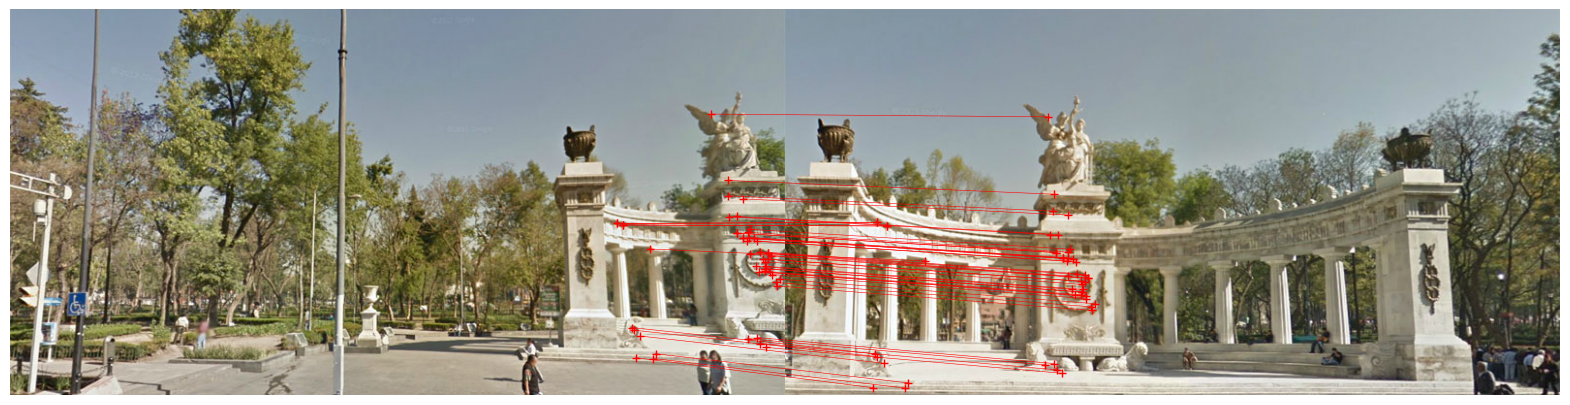

In [ ]:
# Random number generator, 0 seed for reproducibility
rng = np.random.default_rng(0)
# RANSAC parameters
max_iterations = 1000
# Threshold to consider a point as an inlier
inlier_threshold = 3.0
# Length of putative matches
num_matches = len(matched_points_left)
# Flag to store the best inliers found
best_inliers_mask, best_homography = None, None
# Count of inliers in the best homography
max_inliers = 0

for _ in range(max_iterations):
    # Sample indexes for 4 random matches
    idx = rng.choice(num_matches, size=4, replace=False)
    
    # Compute homography for these 4 matches
    homography_candidate = compute_homography(
        matched_points_left[idx],
        matched_points_right[idx]
    )

    # Compute reprojection errors for all matches
    error = reprojection_errors(
        homography_candidate,
        matched_points_left,
        matched_points_right
    )

    # Determine inliers based on the error threshold
    inliers_mask = error < inlier_threshold
    num_inliers = int(np.sum(inliers_mask))

    # Update the best homography if this one has more inliers
    if num_inliers > max_inliers:
        max_inliers = num_inliers
        # Copy used to avoid reference issues
        best_inliers_mask = inliers_mask.copy()
        best_homography = homography_candidate

# Guard if no inliers found
if best_inliers_mask is None or not np.any(best_inliers_mask):
    raise RuntimeError("No inliers found. Try adjusting inlier_threshold or iterations.")

# Re-estimate homography using all inliers from the best model
final_homography = compute_homography(
    matched_points_left[best_inliers_mask],
    matched_points_right[best_inliers_mask]
)

# Compute inverse homography
Hinv = np.linalg.inv(final_homography)

# Calculate and report mean reprojection errors
error_left = reprojection_errors(Hinv, matched_points_left, matched_points_right).mean()
error_right = reprojection_errors(final_homography, matched_points_right, matched_points_left).mean()
print(f"Mean reprojection error (L→R): {error_left:.3f} px")
print(f"Mean reprojection error (R→L): {error_right:.3f} px")

# Refine homography using nonlinear optimization (minimize reprojection loss)
result = minimize(
               # Function to minimize the loss in the optimization
               reprojection_loss,
               # The ravel attribute flattens the 2D array into 1D
               final_homography.ravel(),
               # Additional arguments contains the inlier points
               args=(matched_points_left[best_inliers_mask],
                     matched_points_right[best_inliers_mask]),
               # Method used for optimization is Powell's method
               # This method does not require gradient information
               method='Powell')

# Reshape the optimized homography back to 3x3
refined_homography = result.x.reshape(3,3)
# Normalize the homography matrix
refined_homography /= refined_homography[2,2]
# Update the final homography
final_homography = refined_homography

# Recompute inliers using the final homography
errors_final = reprojection_errors(
    final_homography,
    matched_points_left,
    matched_points_right
)

# If errors_final is less than inlier_threshold, mark as inlier
final_inliers_mask = errors_final < inlier_threshold

# Calculate the average inlier residual (squared)
# Converted the mean to float for consistent formatting
avg_inlier_residual_sq = float(np.mean(errors_final[final_inliers_mask]**2))
print(f"Inliers (final H): {int(final_inliers_mask.sum())} / {len(matched_points_left)}")
print(f"Average inlier residual (squared px, final H): {avg_inlier_residual_sq:.3f}")

# Plot using the final inlier set
inlier_points_left  = matched_points_left[final_inliers_mask]
inlier_points_right = matched_points_right[final_inliers_mask]

# Prepare inlier matches for plotting
inliers_xy = np.column_stack([
    inlier_points_left[:, 0],   # x_left
    inlier_points_left[:, 1],   # y_left
    inlier_points_right[:, 0],  # x_right
    inlier_points_right[:, 1]   # y_right
])

# Plot inlier matchess
fig, ax = plt.subplots(figsize=(20, 10))
# Call the provided function to plot inlier matches
plot_inlier_matches(ax, left_rgb, right_rgb, inliers_xy)

### Image Warping and Geometric Transformation
Apply the estimated homography to warp the left image onto the right image coordinate system

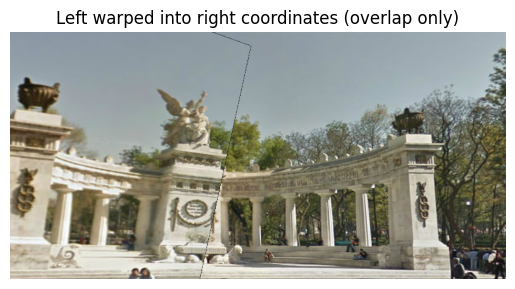

In [12]:
# Grab image dimensions
h_left,  w_left  = left_rgb.shape[:2]
h_right, w_right = right_rgb.shape[:2]

# Create inverse transformation to map from output coordinates to source coordinates
# For warping, need the inverse of H to sample from the left image
homography_inverse = np.linalg.inv(final_homography)
to_left_coords = ProjectiveTransform(homography_inverse)

# Warp the left image into the right image's coordinate frame size, just to check alignment.
warped_left_in_right_frame = warp(
    left_rgb,
    to_left_coords,
    output_shape=(h_right, w_right)
)

# Create masks for blending
mask_left = (warped_left_in_right_frame.sum(axis=2) > 0).astype(float)
mask_right = (right_rgb.sum(axis=2) > 0).astype(float)

# Blend using simple alpha blending, favoring the right image where both overlap
alpha = np.clip(mask_left, 0, 1)
# Generate the overlay image
overlay = alpha[...,None] * warped_left_in_right_frame + (1 - alpha[...,None]) * right_rgb

# Visualize the overlay of the warped left image and the right image
plt.imshow(overlay)
plt.title("Left warped into right coordinates (overlap only)")
plt.axis('off')
plt.show()


### Create Panoramic Image
Create a new image big enough to hold the panorama and composite the two images into it.

Panorama size (h,w): 1351 2647


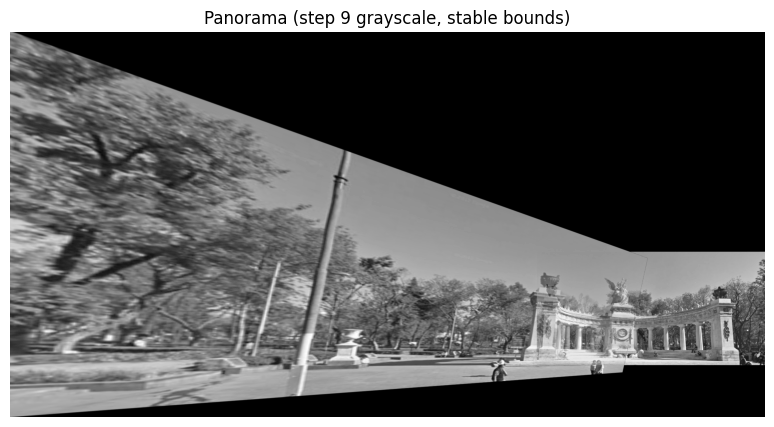

In [13]:
left_gray  = color.rgb2gray(left_rgb)
right_gray = color.rgb2gray(right_rgb)

hL, wL = left_gray.shape
hR, wR = right_gray.shape

# Helper
def apply_homography(H, pts_xy):
    homog = np.hstack([pts_xy, np.ones((pts_xy.shape[0],1))])
    warped = homog @ H.T
    warped_xy = warped[:, :2] / warped[:, [2]]
    return warped_xy

# --- sample only boundary points, not just 4 corners ---
xs = np.linspace(0, wL-1, 50)
ys = np.linspace(0, hL-1, 50)
boundary = []
for x in xs:
    boundary.append([x, 0])
    boundary.append([x, hL-1])
for y in ys:
    boundary.append([0, y])
    boundary.append([wL-1, y])
boundary = np.array(boundary, dtype=np.float32)

# project boundary to right frame
proj = apply_homography(final_homography, boundary)

# keep only reasonable projections
keep = (
    (proj[:,0] > -2000) & (proj[:,0] < wR + 2000) &
    (proj[:,1] > -2000) & (proj[:,1] < hR + 2000)
)
proj = proj[keep]

# corners of right image in right coords
right_corners = np.array([
    [0,0],
    [wR-1,0],
    [wR-1,hR-1],
    [0,hR-1]
], dtype=np.float32)

# combine
all_pts = np.vstack([proj, right_corners])

min_x = int(np.floor(all_pts[:,0].min()))
min_y = int(np.floor(all_pts[:,1].min()))
max_x = int(np.ceil(all_pts[:,0].max()))
max_y = int(np.ceil(all_pts[:,1].max()))

pan_w = max_x - min_x + 1
pan_h = max_y - min_y + 1
print("Panorama size (h,w):", pan_h, pan_w)

# translation
T = np.array([
    [1, 0, -min_x],
    [0, 1, -min_y],
    [0, 0, 1]
], dtype=np.float32)

H_left_to_pan  = T @ final_homography
H_right_to_pan = T

# warp both
H_left_inv = np.linalg.inv(H_left_to_pan)
H_right_inv = np.linalg.inv(H_right_to_pan)
tform_left  = ProjectiveTransform(H_left_inv)
tform_right = ProjectiveTransform(H_right_inv)

left_pan  = warp(left_gray,  tform_left,  output_shape=(pan_h, pan_w))
right_pan = warp(right_gray, tform_right, output_shape=(pan_h, pan_w))

# blend
mask_left  = left_pan  > 0
mask_right = right_pan > 0
both = mask_left & mask_right

panorama = np.zeros((pan_h, pan_w))
panorama[mask_left & ~mask_right]  = left_pan[mask_left & ~mask_right]
panorama[mask_right & ~mask_left]  = right_pan[mask_right & ~mask_left]
panorama[both] = 0.5*left_pan[both] + 0.5*right_pan[both]

plt.figure(figsize=(12,5))
plt.imshow(panorama, cmap='gray')
plt.axis('off')
plt.title('Panorama (step 9 grayscale, stable bounds)')
plt.show()


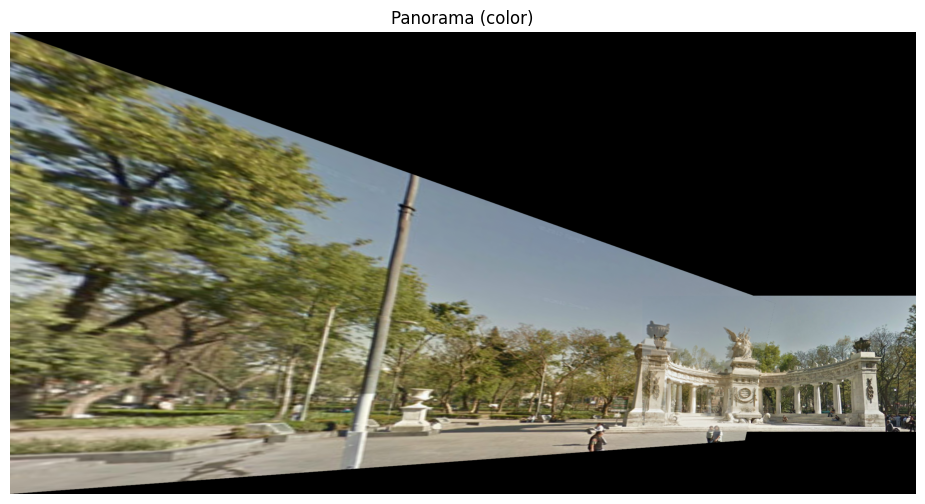

In [14]:
# Warp the RGB images into the panorama canvas
left_pan_rgb  = warp(left_rgb,  tform_left,  output_shape=(pan_h, pan_w), preserve_range=True)
right_pan_rgb = warp(right_rgb, tform_right, output_shape=(pan_h, pan_w), preserve_range=True)

# Robust binary masks via warping ones with nearest-neighbor (avoids fractional nonzeros)
left_mask = warp(
    np.ones(left_rgb.shape[:2], dtype=float),
    tform_left,
    output_shape=(pan_h, pan_w),
    order=0,
    preserve_range=True
) > 0.5

right_mask = warp(
    np.ones(right_rgb.shape[:2], dtype=float),
    tform_right,
    output_shape=(pan_h, pan_w),
    order=0,
    preserve_range=True
) > 0.5

only_left  = left_mask & ~right_mask
only_right = right_mask & ~left_mask
both = left_mask & right_mask

# Composite
panorama_rgb = np.zeros((pan_h, pan_w, 3), dtype=float)
panorama_rgb[only_left]  = left_pan_rgb[only_left]
panorama_rgb[only_right] = right_pan_rgb[only_right]
panorama_rgb[both]       = 0.5 * left_pan_rgb[both] + 0.5 * right_pan_rgb[both]

# Display (float in [0,1])
panorama_rgb_disp = np.clip(panorama_rgb, 0, 1)

plt.figure(figsize=(14, 6))
plt.imshow(panorama_rgb_disp)
plt.axis('off')
plt.title('Panorama (color)')
plt.show()